In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../ablation_study/ablation_results.csv')
print(df)
print(f"\nColumns: {list(df.columns)}")
print(f"Configs: {df['Config'].unique()}")

         Dataset         Config  Accuracy        F1  Leaves  Nodes  Depth  \
0   BanknoteAuth  SR-CCP (full)  0.987420  0.987270     8.4   15.8    5.2   
1   BanknoteAuth       No Depth  0.943886  0.943122     8.4   15.8    5.4   
2   BanknoteAuth     No Feature  0.982503  0.982299    22.0   43.0    8.4   
3   BanknoteAuth   No Penalties  0.981776  0.981564    23.6   46.2    8.6   
4   BreastCancer  SR-CCP (full)  0.943770  0.939600     3.2    5.4    3.0   
5   BreastCancer       No Depth  0.938519  0.934419     6.2   11.4    4.2   
6   BreastCancer     No Feature  0.935010  0.930470     5.2    9.4    3.6   
7   BreastCancer   No Penalties  0.933209  0.928497    10.2   19.4    5.4   
8   HeartDisease  SR-CCP (full)  0.796300  0.792030     6.0   11.0    4.4   
9   HeartDisease       No Depth  0.737037  0.725743     6.2   11.4    4.6   
10  HeartDisease     No Feature  0.748148  0.738467     6.6   12.2    4.4   
11  HeartDisease   No Penalties  0.733333  0.727246    12.4   23.8    5.6   

In [2]:
# --- Summary table ---
summary = df.groupby('Config')[['Accuracy', 'Leaves', 'Nodes', 'Depth', 'n_Features']].mean()
print(summary.round(4))

               Accuracy   Leaves    Nodes   Depth  n_Features
Config                                                       
No Depth         0.8704   6.9714  12.9429  4.7429      4.6000
No Feature       0.8787  12.8571  24.7143  6.1714      6.9429
No Penalties     0.8758  20.2571  39.5143  7.4857      9.8857
SR-CCP (full)    0.8947   5.0286   9.0571  3.8571      3.2000


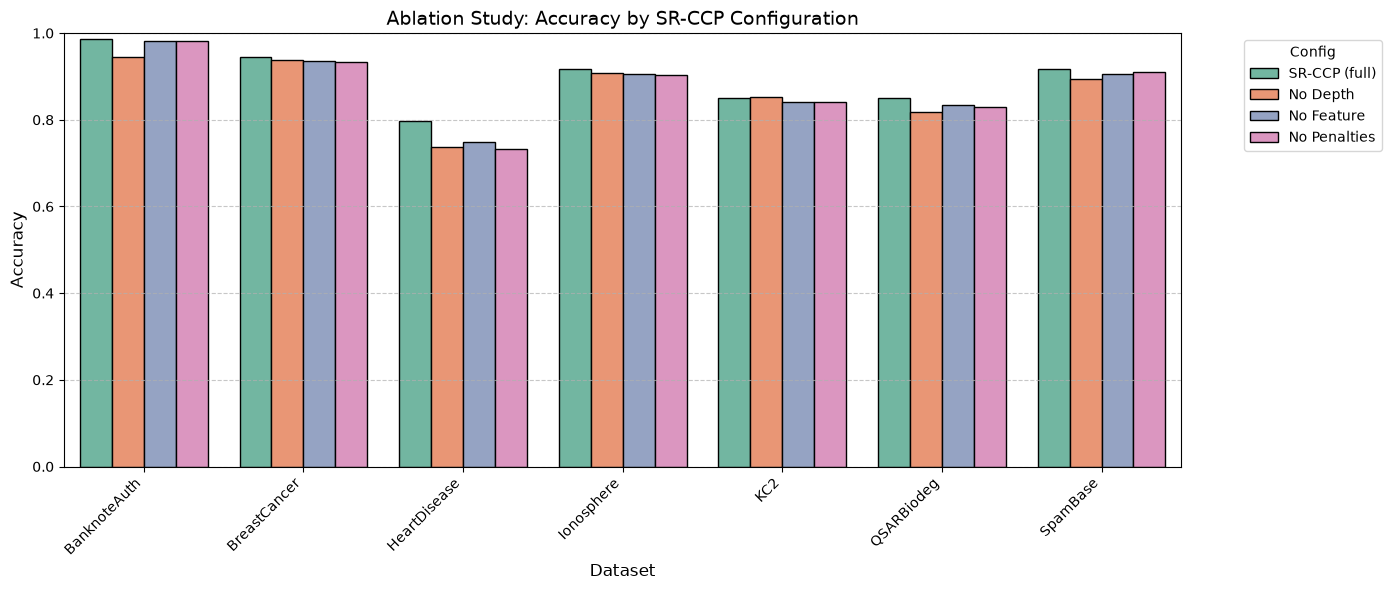

In [3]:
# --- Chart 1: Accuracy per config per dataset ---
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df, x='Dataset', y='Accuracy', hue='Config', palette='Set2', edgecolor='black')
plt.title('Ablation Study: Accuracy by SR-CCP Configuration', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ablation_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

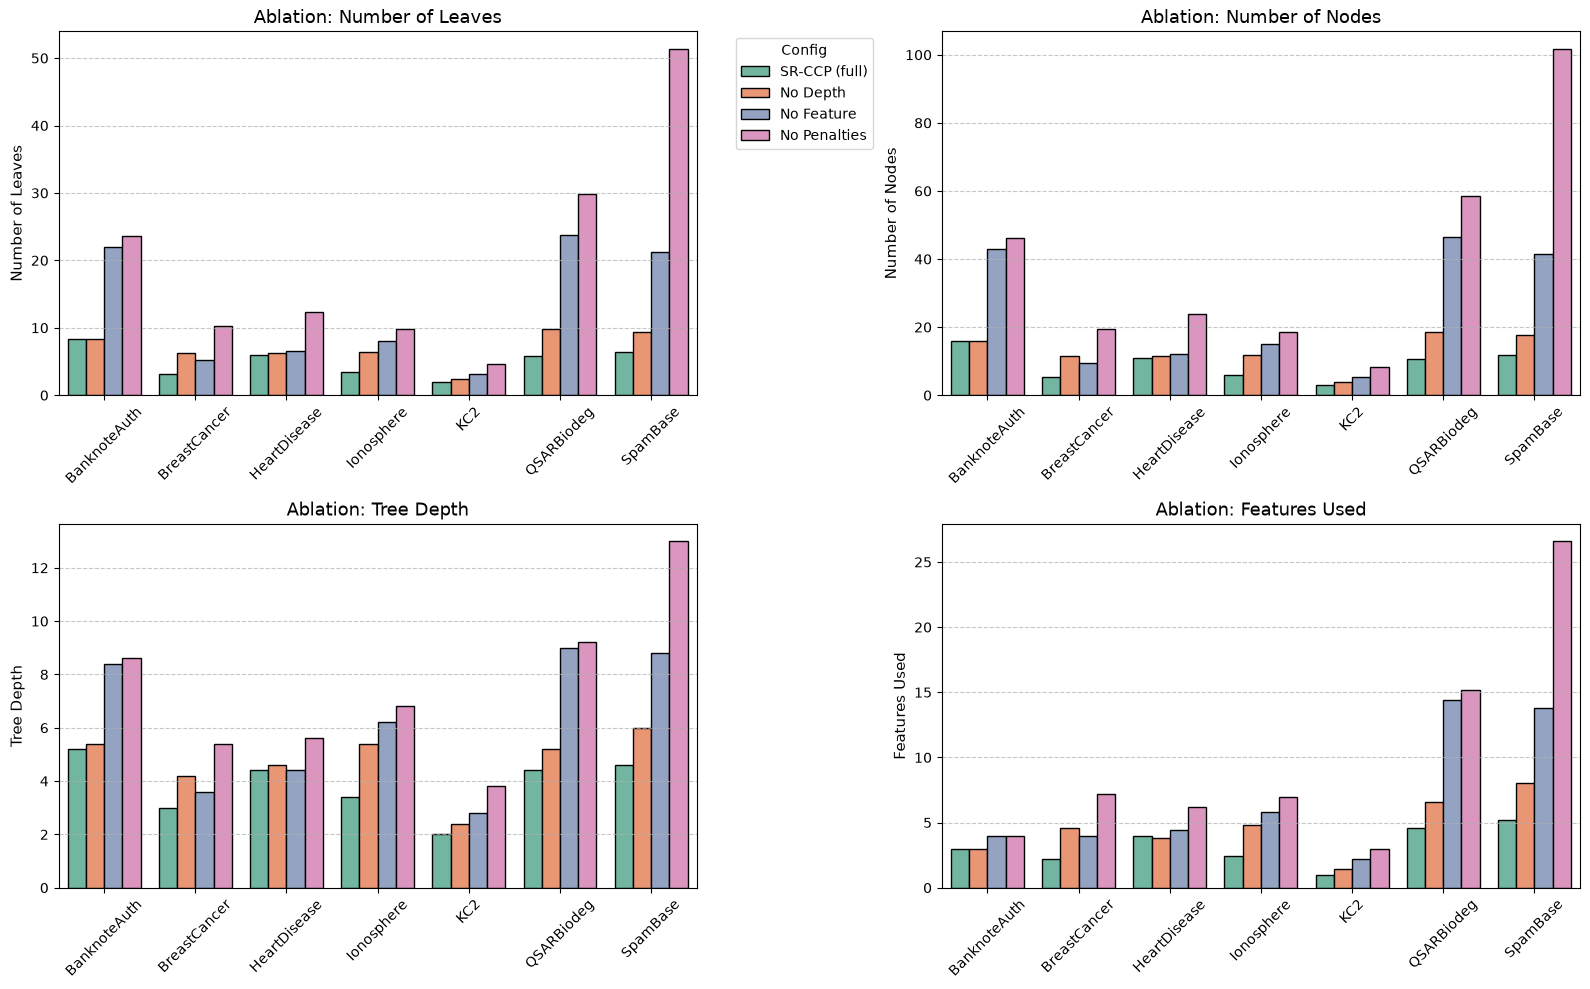

In [4]:
# --- Chart 2: Tree complexity (Leaves, Nodes, Depth, n_Features) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col, title in zip(axes.flat, ['Leaves', 'Nodes', 'Depth', 'n_Features'],
                         ['Number of Leaves', 'Number of Nodes', 'Tree Depth', 'Features Used']):
    sns.barplot(data=df, x='Dataset', y=col, hue='Config', palette='Set2', edgecolor='black', ax=ax)
    ax.set_title(f'Ablation: {title}', fontsize=13)
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if ax != axes[0, 0]:
        ax.get_legend().remove()
axes[0, 0].legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ablation_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# --- Delta from full SR-CCP ---
full = df[df['Config'] == 'SR-CCP (full)'].set_index('Dataset')
print('DELTA vs SR-CCP (full)')
print('='*60)
for cfg in ['No Depth', 'No Feature', 'No Penalties']:
    partial = df[df['Config'] == cfg].set_index('Dataset')
    delta_acc = partial['Accuracy'] - full['Accuracy']
    delta_feat = partial['n_Features'] - full['n_Features']
    delta_leaves = partial['Leaves'] - full['Leaves']
    print(f"\n{cfg} vs SR-CCP:")
    print(f"  Mean ΔAccuracy: {delta_acc.mean():+.4f}")
    print(f"  Mean ΔFeatures: {delta_feat.mean():+.1f}")
    print(f"  Mean ΔLeaves:   {delta_leaves.mean():+.1f}")

DELTA vs SR-CCP (full)

No Depth vs SR-CCP:
  Mean ΔAccuracy: -0.0243
  Mean ΔFeatures: +1.4
  Mean ΔLeaves:   +1.9

No Feature vs SR-CCP:
  Mean ΔAccuracy: -0.0159
  Mean ΔFeatures: +3.7
  Mean ΔLeaves:   +7.8

No Penalties vs SR-CCP:
  Mean ΔAccuracy: -0.0188
  Mean ΔFeatures: +6.7
  Mean ΔLeaves:   +15.2
